# 🏥 Healthcare Veri Seti — Data Science Bitirme Projesi

**Veri Seti:** [Kaggle — Healthcare Dataset (prasad22)](https://www.kaggle.com/datasets/prasad22/healthcare-dataset)  
**Hedef:** Hasta test sonucunu tahmin etmek (Normal / Abnormal / Inconclusive)  
**İkincil Hedef:** Fatura tutarını tahmin etmek (Regression)

---

## Proje Akışı
1. Kütüphane ve Veri Yükleme  
2. Keşifsel Veri Analizi (EDA)  
3. Veri Ön İşleme  
4. Classification — Test Sonucu Tahmini  
5. Regression — Fatura Tahmini  
6. Model Karşılaştırması ve Sonuç

## 1. Kütüphane ve Veri Yükleme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)
import joblib

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Tüm kütüphaneler başarıyla yüklendi.')

Tüm kütüphaneler başarıyla yüklendi.


In [2]:
# Kaggle'dan indirip aynı klasöre koyun: healthcare_dataset.csv
df = pd.read_csv('../data/healthcare_dataset.csv')

print(f'Satır sayısı : {df.shape[0]:,}')
print(f'Sütun sayısı : {df.shape[1]}')
print(f'\nSütunlar:')
print(df.columns.tolist())
df.head()

Satır sayısı : 55,500
Sütun sayısı : 15

Sütunlar:
['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [3]:
print('=== Veri Tipleri & Eksik Değer Kontrolü ===')
info = pd.DataFrame({
    'dtype': df.dtypes,
    'null_sayisi': df.isnull().sum(),
    'null_yuzde': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info)

print('\n=== Temel İstatistikler ===')
df.describe()

=== Veri Tipleri & Eksik Değer Kontrolü ===
                      dtype  null_sayisi  null_yuzde
Name                 object            0         0.0
Age                   int64            0         0.0
Gender               object            0         0.0
Blood Type           object            0         0.0
Medical Condition    object            0         0.0
Date of Admission    object            0         0.0
Doctor               object            0         0.0
Hospital             object            0         0.0
Insurance Provider   object            0         0.0
Billing Amount      float64            0         0.0
Room Number           int64            0         0.0
Admission Type       object            0         0.0
Discharge Date       object            0         0.0
Medication           object            0         0.0
Test Results         object            0         0.0

=== Temel İstatistikler ===


,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


# 2. Keşifsel Veri Analizi (EDA)
## 2.1 Sayısal Değişkenler


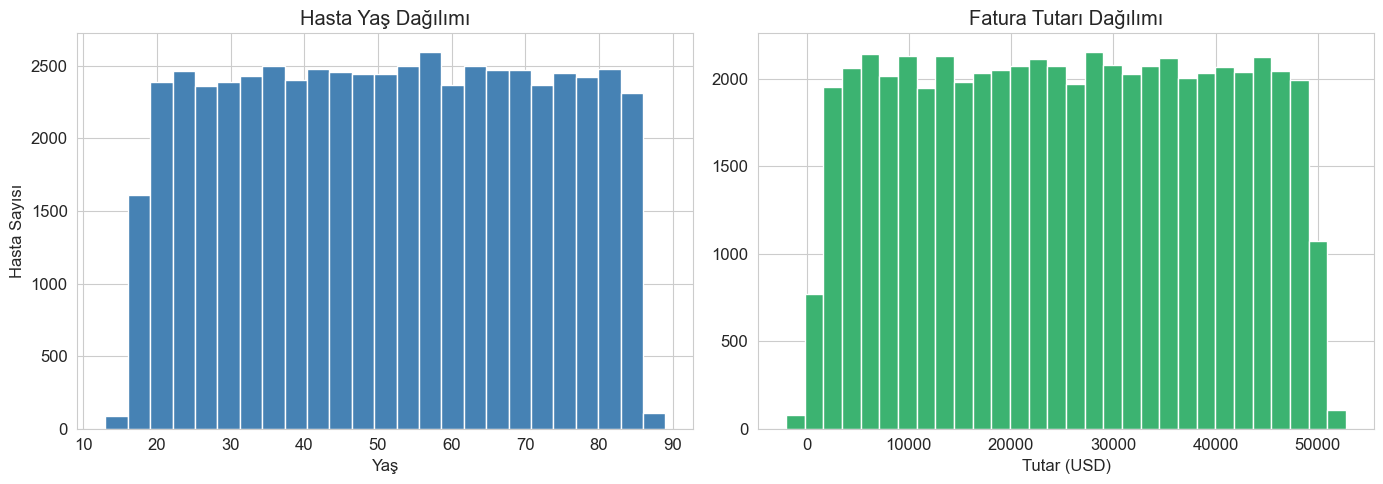

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Age'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Hasta Yaş Dağılımı')
axes[0].set_xlabel('Yaş')
axes[0].set_ylabel('Hasta Sayısı')

axes[1].hist(df['Billing Amount'], bins=30, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Fatura Tutarı Dağılımı')
axes[1].set_xlabel('Tutar (USD)')

plt.tight_layout()
plt.savefig('eda_sayisal.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.2 Kategorik Değişkenler

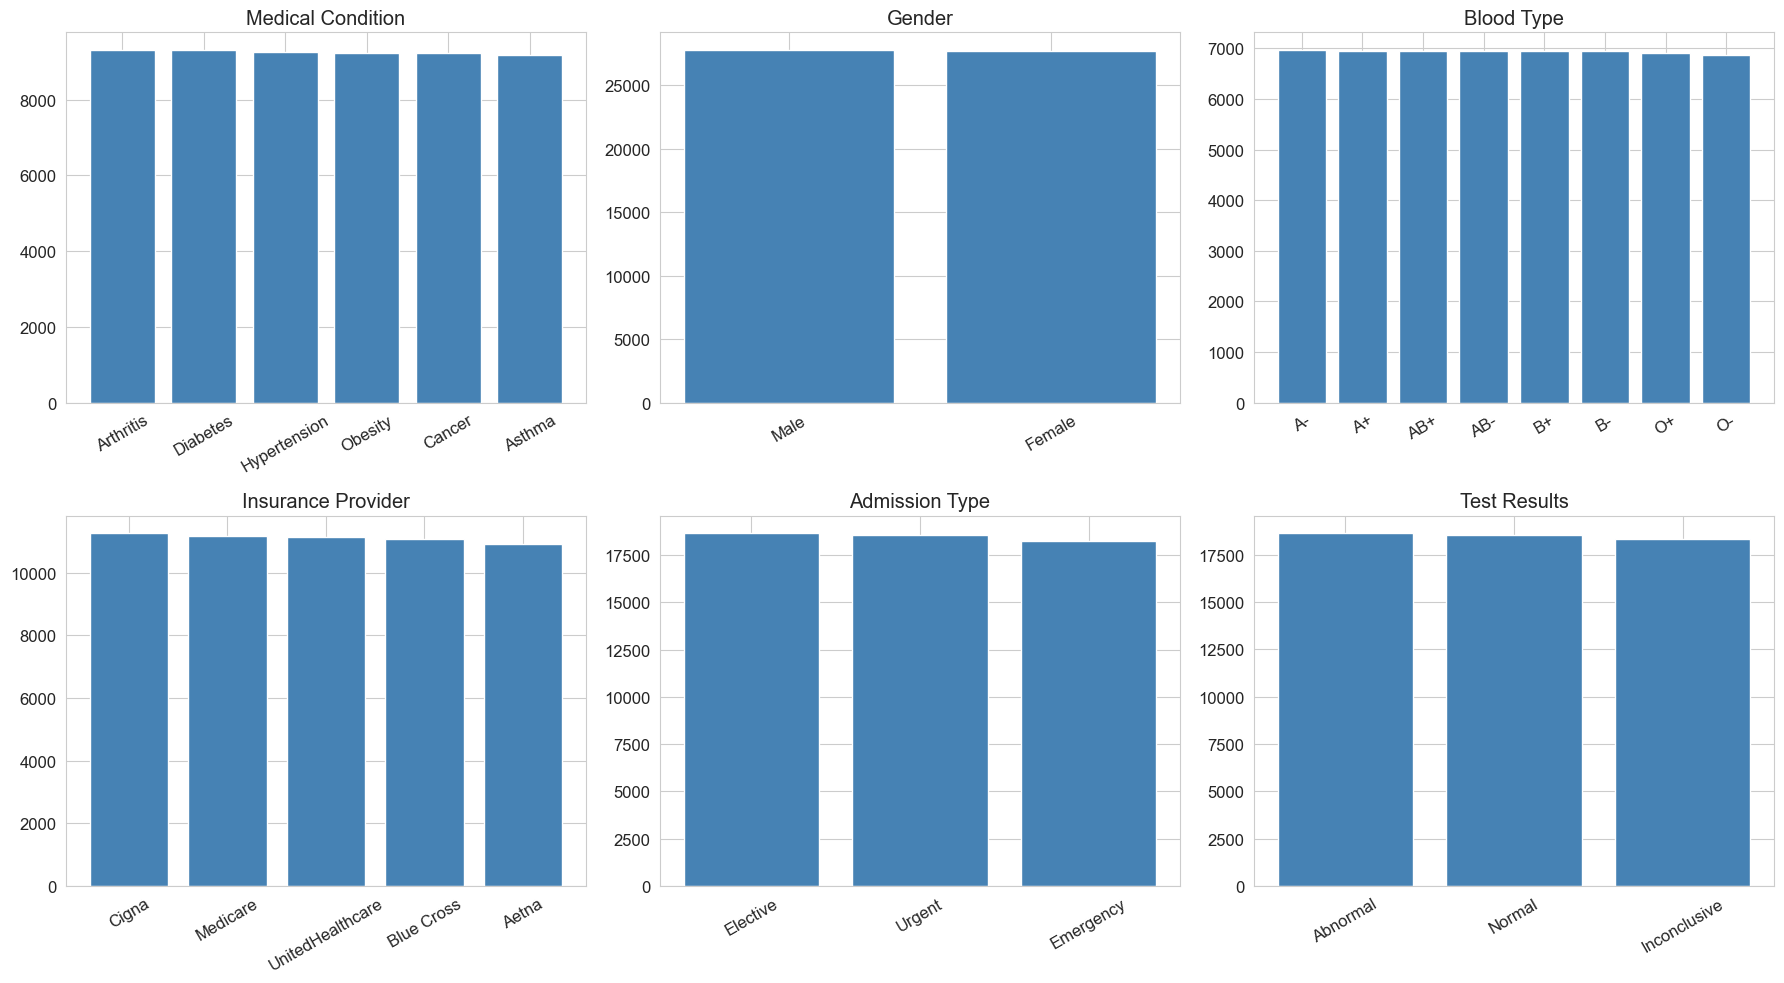

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cat_cols = ['Medical Condition', 'Gender', 'Blood Type',
            'Insurance Provider', 'Admission Type', 'Test Results']

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_kategorik.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.3 Hedef Değişken Analizi — Test Sonucu

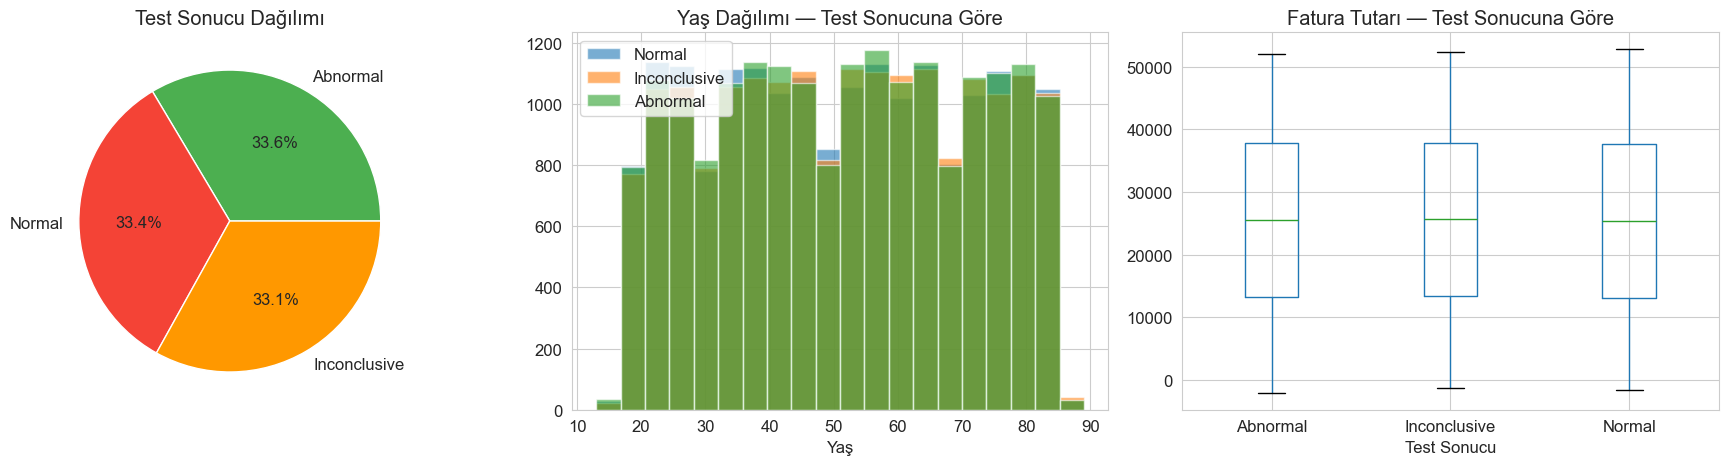

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Test sonucu dağılımı
test_counts = df['Test Results'].value_counts()
axes[0].pie(test_counts.values, labels=test_counts.index,
            autopct='%1.1f%%', colors=['#4CAF50','#F44336','#FF9800'])
axes[0].set_title('Test Sonucu Dağılımı')

# Yaş vs Test Sonucu
for result in df['Test Results'].unique():
    subset = df[df['Test Results'] == result]['Age']
    axes[1].hist(subset, bins=20, alpha=0.6, label=result)
axes[1].set_title('Yaş Dağılımı — Test Sonucuna Göre')
axes[1].set_xlabel('Yaş')
axes[1].legend()

# Fatura vs Test Sonucu
df.boxplot(column='Billing Amount', by='Test Results', ax=axes[2])
axes[2].set_title('Fatura Tutarı — Test Sonucuna Göre')
axes[2].set_xlabel('Test Sonucu')
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_hedef.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.4 Korelasyon Matrisi

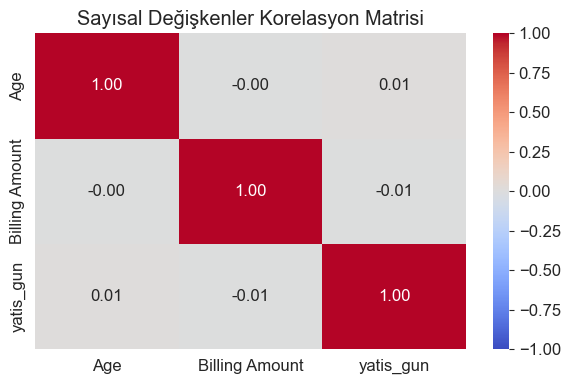

In [7]:
num_df = df[['Age', 'Billing Amount']].copy()

# Yatış gününü hesapla
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['yatis_gun'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
num_df['yatis_gun'] = df['yatis_gun']

plt.figure(figsize=(6, 4))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Sayısal Değişkenler Korelasyon Matrisi')
plt.tight_layout()
plt.savefig('eda_korelasyon.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Veri Ön İşleme

In [8]:
df_model = df.copy()

# Tarih feature'ları
df_model['admission_ay'] = df_model['Date of Admission'].dt.month
df_model['admission_yil'] = df_model['Date of Admission'].dt.year

# Label Encoding
le = LabelEncoder()
cat_cols = ['Gender', 'Blood Type', 'Medical Condition',
            'Insurance Provider', 'Admission Type', 'Medication']
for col in cat_cols:
    df_model[col + '_enc'] = le.fit_transform(df_model[col])

# Hedef değişkenler
df_model['test_target'] = le.fit_transform(df_model['Test Results'])  # 0,1,2
target_map = dict(zip(le.transform(le.classes_), le.classes_))
print('Hedef sınıf eşleştirmesi:', target_map)

# Feature listesi
features = ['Age', 'yatis_gun', 'Billing Amount', 'admission_ay',
            'Gender_enc', 'Blood Type_enc', 'Medical Condition_enc',
            'Insurance Provider_enc', 'Admission Type_enc', 'Medication_enc']

X = df_model[features]
y_cls = df_model['test_target']
y_reg = df_model['Billing Amount']

print(f'\nFeature sayısı: {X.shape[1]}')
print(f'Örnek sayısı : {X.shape[0]:,}')
print(f'\nHedef dağılımı (classification):')
print(y_cls.value_counts())

Hedef sınıf eşleştirmesi: {0: 'Abnormal', 1: 'Inconclusive', 2: 'Normal'}

Feature sayısı: 10
Örnek sayısı : 55,500

Hedef dağılımı (classification):
test_target
0    18627
2    18517
1    18356
Name: count, dtype: int64


In [9]:
X_train, X_test, y_train_cls, y_test_cls = train_test_split(
    X, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
_, _, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Eğitim seti: {X_train.shape[0]:,} satır')
print(f'Test seti  : {X_test.shape[0]:,} satır')

Eğitim seti: 44,400 satır
Test seti  : 11,100 satır


## 4. Classification — Test Sonucu Tahmini

### 4.1 Cross-Validation ile Model Karşılaştırması

Logistic Regression       CV Accuracy: 0.331 ± 0.003
Decision Tree             CV Accuracy: 0.395 ± 0.005
KNN                       CV Accuracy: 0.362 ± 0.004
Random Forest             CV Accuracy: 0.416 ± 0.003
Gradient Boosting         CV Accuracy: 0.341 ± 0.004


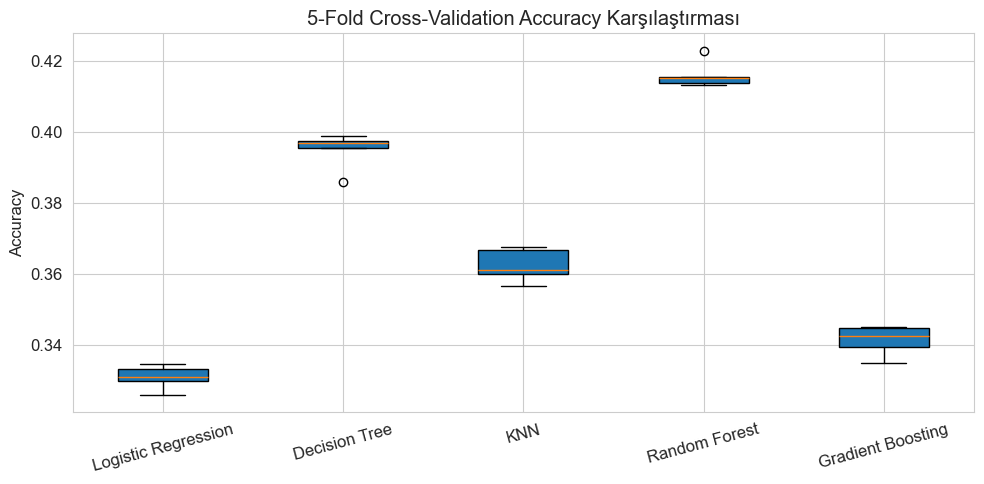

In [10]:
cls_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

cv_results = {}
for name, model in cls_models.items():
    scores = cross_val_score(model, X_train_sc, y_train_cls, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:<25} CV Accuracy: {scores.mean():.3f} ± {scores.std():.3f}')

# Görselleştirme
fig, ax = plt.subplots(figsize=(10, 5))
positions = range(len(cv_results))
ax.boxplot(cv_results.values(), tick_labels=cv_results.keys(), patch_artist=True)
ax.set_title('5-Fold Cross-Validation Accuracy Karşılaştırması')
ax.set_ylabel('Accuracy')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('cv_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Hiperparametre Optimizasyonu (GridSearchCV)

In [11]:
# Random Forest için GridSearch
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_sc, y_train_cls)

print(f'\nEn iyi parametreler: {grid_search.best_params_}')
print(f'En iyi CV Accuracy : {grid_search.best_score_:.3f}')
best_cls_model = grid_search.best_estimator_

Fitting 3 folds for each of 18 candidates, totalling 54 fits

En iyi parametreler: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
En iyi CV Accuracy : 0.403


### 4.3 Test Seti Değerlendirmesi

=== Test Seti Sonuçları ===
Accuracy: 0.434

              precision    recall  f1-score   support

    Abnormal       0.43      0.44      0.44      3726
Inconclusive       0.43      0.42      0.42      3671
      Normal       0.44      0.44      0.44      3703

    accuracy                           0.43     11100
   macro avg       0.43      0.43      0.43     11100
weighted avg       0.43      0.43      0.43     11100



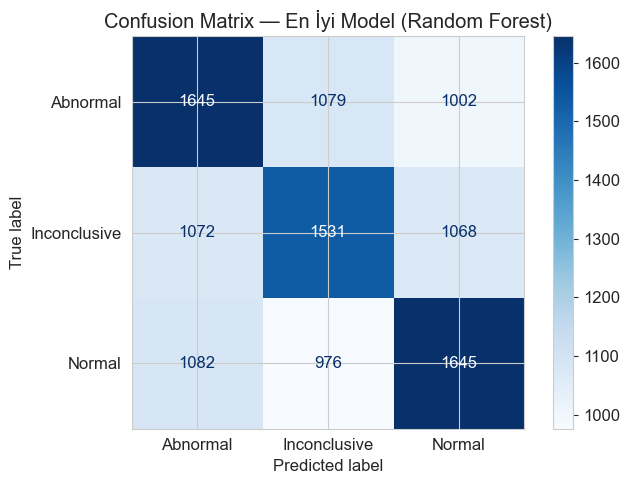

In [12]:
y_pred_cls = best_cls_model.predict(X_test_sc)

print('=== Test Seti Sonuçları ===')
print(f'Accuracy: {accuracy_score(y_test_cls, y_pred_cls):.3f}')
print()
print(classification_report(
    y_test_cls, y_pred_cls,
    target_names=list(target_map.values())
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_cls, y_pred_cls,
    display_labels=list(target_map.values()),
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — En İyi Model (Random Forest)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Feature Importance

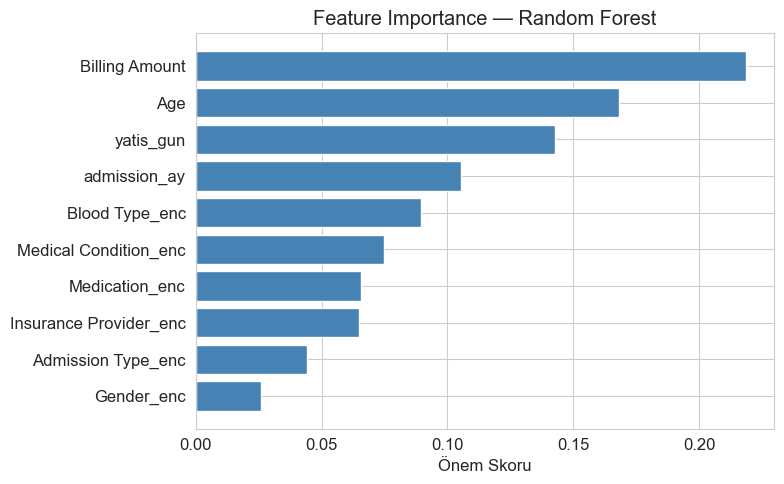


En önemli 3 feature:
       feature  importance
Billing Amount    0.218719
           Age    0.167977
     yatis_gun    0.142867


In [13]:
importances = best_cls_model.feature_importances_
feat_df = pd.DataFrame({'feature': features, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['feature'], feat_df['importance'], color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Önem Skoru')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nEn önemli 3 feature:')
print(feat_df.sort_values('importance', ascending=False).head(3).to_string(index=False))

### 4.5 Learning Curve — Overfitting/Underfitting Kontrolü

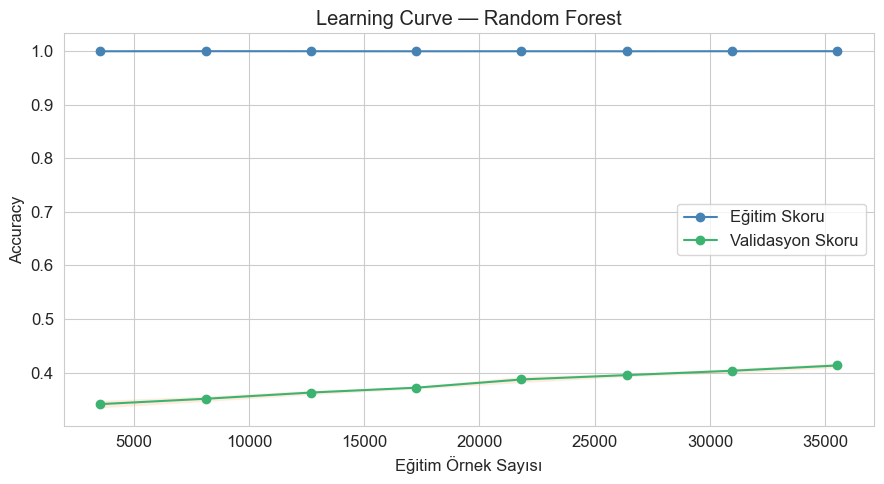

In [14]:
train_sizes, train_scores, val_scores = learning_curve(
    best_cls_model, X_train_sc, y_train_cls,
    cv=5, train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='accuracy', n_jobs=-1
)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Eğitim Skoru', color='steelblue')
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15)
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validasyon Skoru', color='mediumseagreen')
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15)
plt.title('Learning Curve — Random Forest')
plt.xlabel('Eğitim Örnek Sayısı')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Regression — Fatura Tutarı Tahmini

### 5.1 Model Eğitimi ve Cross-Validation

In [15]:
X_r = df_model[features].drop(columns=['Billing Amount'])
y_r = df_model['Billing Amount']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42
)
Xr_train_sc = scaler.fit_transform(Xr_train)
Xr_test_sc  = scaler.transform(Xr_test)

reg_models = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Random Forest Reg' : RandomForestRegressor(n_estimators=100, random_state=42)
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(Xr_train_sc, yr_train)
    y_pred_r = model.predict(Xr_test_sc)
    mae  = mean_absolute_error(yr_test, y_pred_r)
    rmse = np.sqrt(mean_squared_error(yr_test, y_pred_r))
    r2   = r2_score(yr_test, y_pred_r)
    reg_results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f'{name:<22} MAE: ${mae:,.0f}  RMSE: ${rmse:,.0f}  R²: {r2:.3f}')

Linear Regression      MAE: $12,193  RMSE: $14,110  R²: -0.001
Ridge Regression       MAE: $12,193  RMSE: $14,110  R²: -0.001
Random Forest Reg      MAE: $11,647  RMSE: $13,741  R²: 0.051


### 5.2 Tahmin vs Gerçek Değer

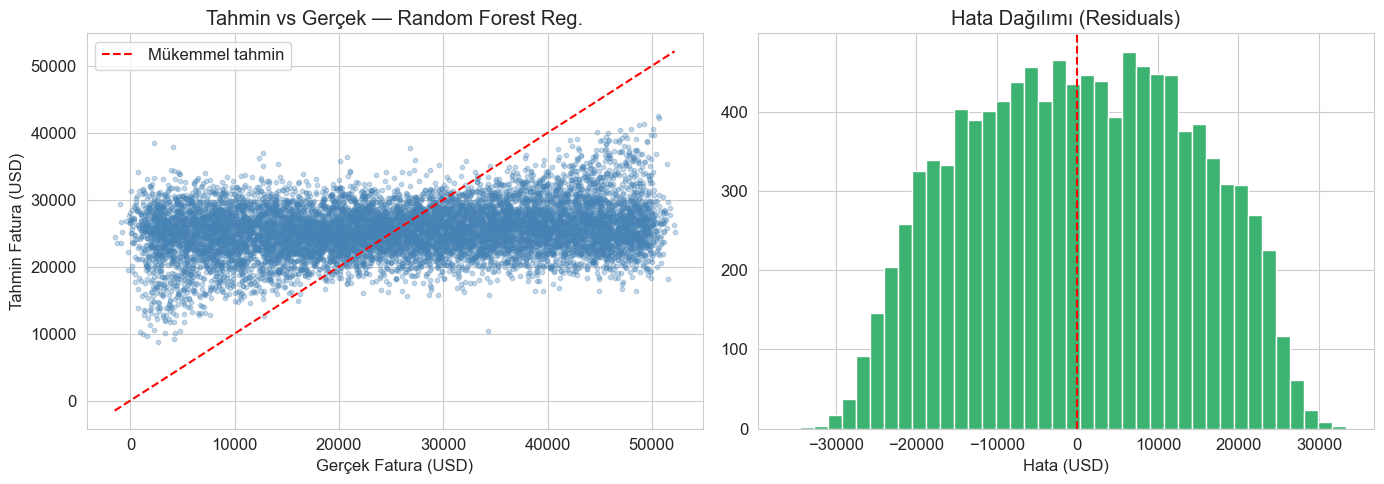

In [16]:
best_reg = RandomForestRegressor(n_estimators=100, random_state=42)
best_reg.fit(Xr_train_sc, yr_train)
yr_pred = best_reg.predict(Xr_test_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tahmin vs gerçek
axes[0].scatter(yr_test, yr_pred, alpha=0.3, s=10, color='steelblue')
lims = [yr_test.min(), yr_test.max()]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Mükemmel tahmin')
axes[0].set_xlabel('Gerçek Fatura (USD)')
axes[0].set_ylabel('Tahmin Fatura (USD)')
axes[0].set_title('Tahmin vs Gerçek — Random Forest Reg.')
axes[0].legend()

# Residuals
residuals = yr_test - yr_pred
axes[1].hist(residuals, bins=40, color='mediumseagreen', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Hata Dağılımı (Residuals)')
axes[1].set_xlabel('Hata (USD)')

plt.tight_layout()
plt.savefig('regression_sonuc.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Genel Sonuç Özeti ve Model Kaydetme

In [20]:
print('=' * 60)
print('PROJE SONUÇ ÖZETİ')
print('=' * 60)

print('\n--- CLASSIFICATION (Test Sonucu Tahmini) ---')
print(f'En iyi model     : Random Forest (GridSearchCV ile optimize)')
print(f'Test Accuracy    : {accuracy_score(y_test_cls, y_pred_cls):.3f}')
print(f'En önemli feature: {feat_df.sort_values("importance", ascending=False).iloc[0]["feature"]}')

print('\n--- REGRESSION (Fatura Tahmini) ---')
for name, m in reg_results.items():
    print(f'{name:<22} R²: {m["R2"]:.3f}  MAE: ${m["MAE"]:,.0f}')

print('\n--- MODEL KAYDETME ---')
joblib.dump(best_cls_model, 'model_classification.pkl')
joblib.dump(best_reg, 'model_regression.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('model_classification.pkl → kaydedildi')
print('model_regression.pkl    → kaydedildi')
print('scaler.pkl              → kaydedildi')
print('\nProje tamamlandı!')

PROJE SONUÇ ÖZETİ

--- CLASSIFICATION (Test Sonucu Tahmini) ---
En iyi model     : Random Forest (GridSearchCV ile optimize)
Test Accuracy    : 0.434
En önemli feature: Billing Amount

--- REGRESSION (Fatura Tahmini) ---
Linear Regression      R²: -0.001  MAE: $12,193
Ridge Regression       R²: -0.001  MAE: $12,193
Random Forest Reg      R²: 0.051  MAE: $11,647

--- MODEL KAYDETME ---
model_classification.pkl → kaydedildi
model_regression.pkl    → kaydedildi
scaler.pkl              → kaydedildi

Proje tamamlandı!
